# How Does Propofol Control Depth of Anaesthesia? A Data-Driven Look at the Propofol–BIS Relationship

## Why does this matter?

Every time you push propofol through an IV line, you are navigating a **dose–response relationship**. Give too little and the patient may be aware during surgery — a devastating complication. Give too much and you risk haemodynamic collapse, prolonged recovery, or even increased postoperative mortality in vulnerable patients.

Modern **target-controlled infusion (TCI) pumps** attempt to automate this balancing act by predicting plasma and effect-site concentrations from pharmacokinetic models. The **Bispectral Index (BIS)** — a processed EEG number between 0 and 100 — gives us a real-time window into the brain's response. Together, propofol dosing and BIS monitoring form the backbone of **intravenous anaesthesia**.

But how well does the dose predict the depth? Is the relationship straightforward, or does it depend on patient factors like age and illness severity? In this chapter we will explore these questions using real data from over 2,000 surgical cases in the VitalDB cohort.

### What you will learn

- **What BIS measures** and what the target range of 40–60 means in practice
- **How propofol dose relates to BIS** across a large surgical population
- **How to read a dual-axis time-series plot** showing drug delivery alongside brain response
- **What factors influence the propofol–BIS relationship** (age, ASA status, surgical approach)
- **How to classify anaesthetic depth adequacy** from BIS data

### A brief note on pharmacokinetics and pharmacodynamics

Before we look at data, it helps to understand two terms you will encounter throughout this chapter:

- **Pharmacokinetics (PK)** answers the question: *"What does the body do to the drug?"* — how propofol is distributed through the bloodstream, taken up by tissues, and eventually eliminated. Think of PK as describing the drug's *journey* through the body.

- **Pharmacodynamics (PD)** answers the complementary question: *"What does the drug do to the body?"* — how a given concentration of propofol at the brain (the "effect site") translates into a clinical effect, measured here by the BIS.

The **PK/PD relationship** links the two: dose → concentration → effect. In later sections we will see that this relationship follows a characteristic **sigmoid (S-shaped) curve** — more on that below.

---

**Cohort:** 2,100 surgical cases from VitalDB that received propofol and had BIS monitoring.

**Approach:**
1. Identify cases with both propofol administration and BIS monitoring
2. Cross-sectional analysis: how does total propofol dose relate to BIS outcomes?
3. Time-series analysis: fetch live BIS and propofol infusion data from the VitalDB API
4. Classify anaesthetic depth adequacy across the cohort

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import io
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR  = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')
API_BASE  = 'https://api.vitaldb.net'

## Who are our patients? Building the study cohort

First, we need to identify which cases in the VitalDB database received propofol *and* had BIS monitoring. Not every surgical case has both — some cases used volatile anaesthetics instead of propofol, and some did not have a BIS monitor attached. By filtering for cases with both, we create a cohort where we can meaningfully study the propofol–BIS relationship.

In [2]:
cases  = pd.read_csv(DATA_DIR / 'all_cases.csv')
tracks = pd.read_csv(DATA_DIR / 'tracks.csv')

# Cases that received propofol
ppf_cases = cases[cases['intraop_ppf'] > 0]['caseid'].tolist()

# Cases with BIS/BIS numeric track
bis_cases = tracks[tracks['tname'] == 'BIS/BIS']['caseid'].tolist()

# Cohort: both
cohort_ids = sorted(set(ppf_cases) & set(bis_cases))
cohort = cases[cases['caseid'].isin(cohort_ids)].copy()

print(f'Cases with propofol          : {len(ppf_cases):,}')
print(f'Cases with BIS/BIS track     : {len(bis_cases):,}')
print(f'Cohort (both)                : {len(cohort_ids):,}')

Cases with propofol          : 2,335
Cases with BIS/BIS track     : 5,867
Cohort (both)                : 2,100


## What propofol data do we actually have?

VitalDB records propofol delivery through the **Orchestra infusion system**, which logs several tracks per case:

- **PPF20_RATE** — the infusion rate (how fast the pump is running)
- **PPF20_VOL** — cumulative volume delivered
- **PPF20_CE** — the *effect-site concentration* (the model's estimate of propofol concentration at the brain)
- **PPF20_CP** — the *plasma concentration* (estimated concentration in the blood)
- **PPF20_CT** — the *target concentration* set by the anaesthesiologist

These tracks come from a **TCI (target-controlled infusion) pump** — a device that uses a pharmacokinetic model (typically the Marsh or Schnider model) to calculate the infusion rate needed to achieve a desired brain concentration. Let us see how many of our cohort cases have these detailed tracks available.

In [3]:
# Find all track names that might contain propofol infusion data
ppf_tracks = tracks[
    tracks['tname'].str.contains('ppf|propofol|PPF|Propofol', case=False, na=False)
]
ppf_track_summary = ppf_tracks.groupby('tname')['caseid'].nunique().sort_values(ascending=False)
print('Propofol-related tracks:')
print(ppf_track_summary.to_string())

Propofol-related tracks:
tname
Orchestra/PPF20_VOL     3512
Orchestra/PPF20_RATE    3512
Orchestra/PPF20_CE      3511
Orchestra/PPF20_CT      3511
Orchestra/PPF20_CP      3511


In [4]:
# Cases in cohort that also have an Orchestra propofol CE track
# Pick the most common propofol track
top_ppf_track = ppf_track_summary.index[0] if len(ppf_track_summary) > 0 else None
print(f'Primary propofol track: {top_ppf_track}')

if top_ppf_track:
    orch_ppf_cases = tracks[
        (tracks['tname'] == top_ppf_track) &
        (tracks['caseid'].isin(cohort_ids))
    ]['caseid'].tolist()
    print(f'Cohort cases with {top_ppf_track}: {len(orch_ppf_cases):,}')

Primary propofol track: Orchestra/PPF20_VOL
Cohort cases with Orchestra/PPF20_VOL: 16


## How much propofol did patients receive?

Before we look at BIS data, let us get a feel for the propofol doses in our cohort. Understanding the *distribution* of doses — how they spread out across patients — will help us interpret the BIS results later.

We will look at three things:
1. **The overall dose distribution** — is it bell-shaped, skewed, or something else?
2. **Dose by ASA class** — do sicker patients (higher ASA) receive different doses?
3. **Dose by surgical approach** — does the type of surgery influence propofol dosing?

*Reminder:* **ASA class** (American Society of Anesthesiologists Physical Status) is a simple 1–5 scale reflecting a patient's overall health before surgery. ASA 1 = healthy; ASA 4 = severe systemic disease that is a constant threat to life.

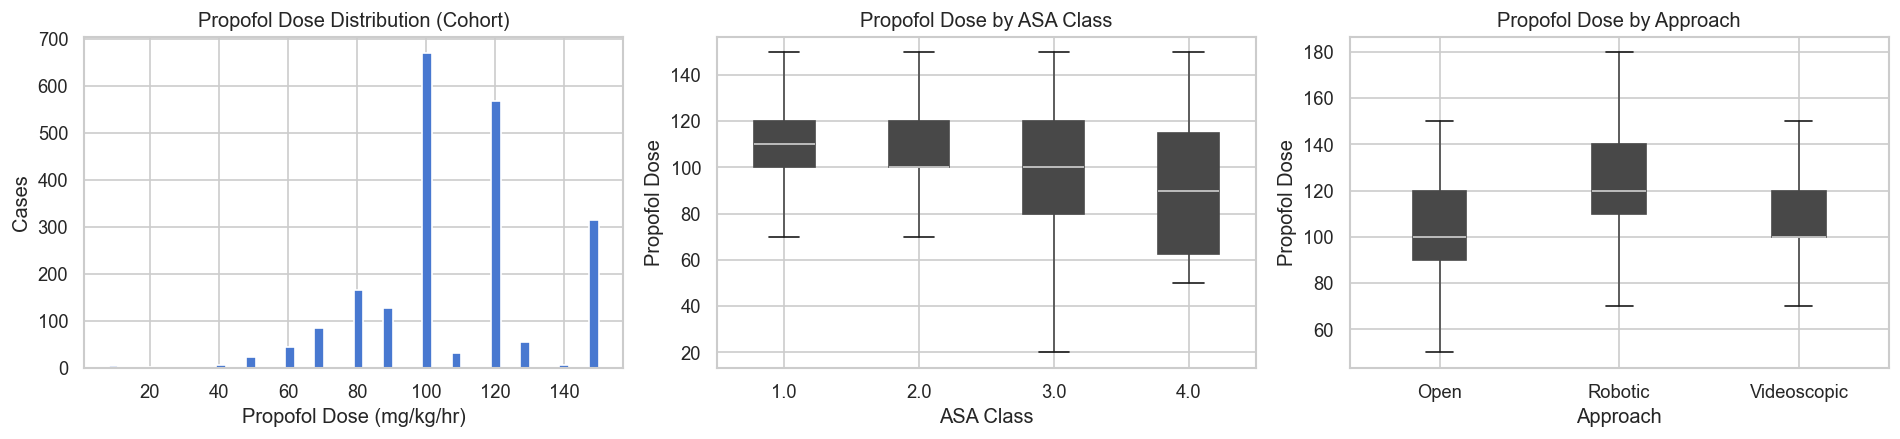

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Propofol dose distribution in cohort
ppf_vals = cohort['intraop_ppf'].clip(upper=cohort['intraop_ppf'].quantile(0.99))
ppf_vals.hist(ax=axes[0], bins=50, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Propofol Dose Distribution (Cohort)')
axes[0].set_xlabel('Propofol Dose (mg/kg/hr)')
axes[0].set_ylabel('Cases')

# Propofol dose by ASA class
cohort.boxplot(column='intraop_ppf', by='asa', ax=axes[1],
               showfliers=False, patch_artist=True)
axes[1].set_title('Propofol Dose by ASA Class')
axes[1].set_xlabel('ASA Class')
axes[1].set_ylabel('Propofol Dose')
plt.sca(axes[1])
plt.title('Propofol Dose by ASA Class')

# Propofol dose by surgical approach
cohort.boxplot(column='intraop_ppf', by='approach', ax=axes[2],
               showfliers=False, patch_artist=True)
axes[2].set_title('Propofol Dose by Surgical Approach')
axes[2].set_xlabel('Approach')
axes[2].set_ylabel('Propofol Dose')
plt.sca(axes[2])
plt.title('Propofol Dose by Approach')

plt.suptitle('')
plt.tight_layout()
plt.show()

### What do these distributions tell us?

The **left panel** shows that most patients received a propofol dose clustered around 100 mg/kg/hr, with a right-skewed tail — a few patients needed considerably higher doses. This is typical of drug dosing in clinical practice: most people fall within a "normal" range, but there is always inter-individual variability.

The **middle panel** (dose by ASA class) is worth pausing on. You might expect sicker patients (higher ASA) to receive *less* propofol because they are more sensitive to its haemodynamic effects. Look at the boxes and see whether that pattern holds in our data.

The **right panel** shows variation by surgical approach, reflecting differences in anaesthetic technique (for example, laparoscopic cases may require different depth targets than open cases).

In [6]:
# Cohort demographics
print('Cohort summary:')
cohort[['age', 'weight', 'height', 'bmi', 'intraop_ppf']].describe().round(2)

Cohort summary:


,age,weight,height,bmi,intraop_ppf
count,2100.00,2100.00,2100.00,2100.00,2100.00
mean,57.10,61.26,162.17,23.22,108.84
std,14.78,11.86,8.79,3.71,25.05
min,8.00,18.70,114.00,11.30,8.00
25%,48.00,52.90,156.20,20.80,100.00
50%,58.00,60.35,162.00,23.10,100.00
75%,68.00,68.40,168.32,25.30,120.00
max,94.00,133.20,187.50,41.40,200.00


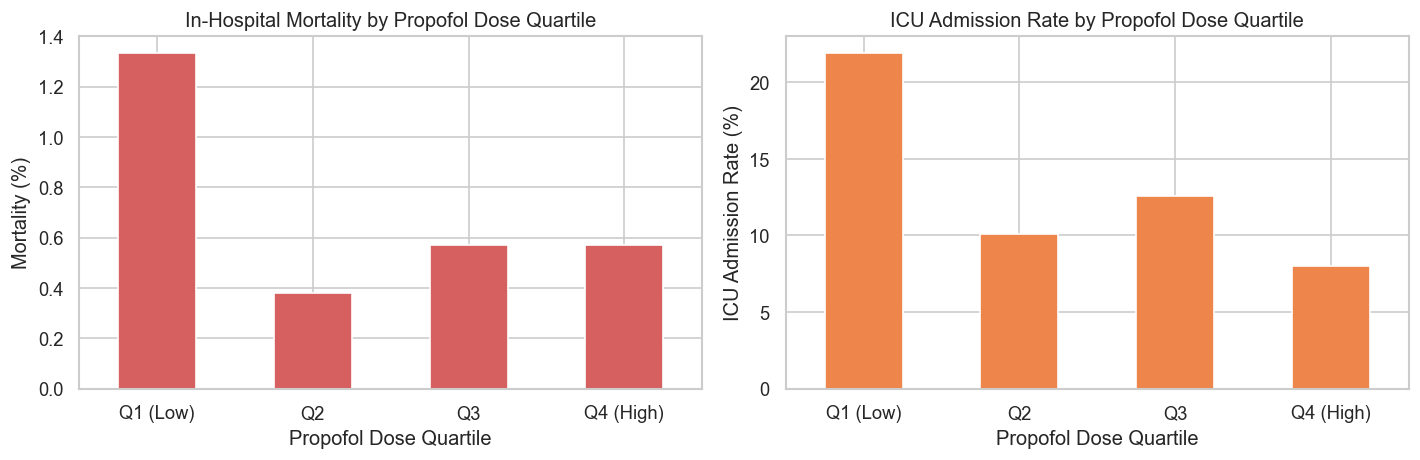

In [7]:
# Propofol dose vs mortality — rank-based qcut avoids duplicate bin edges
cohort['ppf_quartile'] = pd.qcut(
    cohort['intraop_ppf'].rank(method='first'),
    q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)
mort_by_ppf = cohort.groupby('ppf_quartile', observed=True)['death_inhosp'].mean() * 100
icu_by_ppf  = (cohort.groupby('ppf_quartile', observed=True)['icu_days']
               .apply(lambda x: (x > 0).mean()) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mort_by_ppf.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted')[3], edgecolor='white', rot=0)
axes[0].set_title('In-Hospital Mortality by Propofol Dose Quartile')
axes[0].set_ylabel('Mortality (%)')
axes[0].set_xlabel('Propofol Dose Quartile')

icu_by_ppf.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[1], edgecolor='white', rot=0)
axes[1].set_title('ICU Admission Rate by Propofol Dose Quartile')
axes[1].set_ylabel('ICU Admission Rate (%)')
axes[1].set_xlabel('Propofol Dose Quartile')

plt.tight_layout()
plt.show()

### Does higher propofol dose mean worse outcomes?

Be careful with interpretation here. If you see that patients in the highest dose quartile have higher mortality or ICU admission rates, it is tempting to conclude that *propofol itself* caused harm. But this is a classic **confounding** trap: sicker patients, longer surgeries, and more complex procedures may *require* higher doses. The dose is not randomly assigned — the anaesthesiologist chose it based on clinical need.

This is an example of **observational data** — we are watching what happened, not running a randomised controlled trial. We can see *associations* but must be very cautious about claiming *causation*. We will revisit this distinction in later chapters on causal inference.

## Can we watch propofol and BIS in real time?

So far we have looked at *summary* numbers — total propofol dose and average BIS for each case. But anaesthesia is a **dynamic process**. The propofol infusion rate changes minute by minute, and the BIS responds (with a short delay) to those changes.

To see this interplay, we need **time-series data** — a recording of both variables over the course of the operation. VitalDB's API lets us fetch the raw BIS signal and the Orchestra propofol track for individual cases.

Think of it like watching the anaesthetic unfold in fast-forward: the propofol goes up, and a few minutes later the BIS comes down. The propofol is reduced, and the BIS drifts back up. This is the **dose–response relationship playing out in real time**.

### The sigmoid Emax model: turning up the volume

The relationship between propofol concentration and its effect on the brain is not a straight line. Instead, it follows a characteristic **sigmoid (S-shaped) curve**, sometimes called the **Hill equation** or **Emax model**. Here is an intuitive way to think about it:

Imagine turning up a volume dial from 0 to 10:
- At first (low concentrations), turning the dial barely changes the sound — the drug has little effect.
- In the middle range, small turns produce big changes — this is the **steep** part of the curve where clinical titration happens.
- At high settings, the sound is already near maximum and further turning does little — the effect is **saturated**.

The key parameter of this curve is the **EC50** (the concentration that produces 50% of the maximum effect). For propofol and BIS, the EC50 tells us: *"At what effect-site concentration does the BIS drop halfway to its minimum?"* This single number captures much of a patient's individual sensitivity to propofol.

Mathematically:

$$
E = E_0 - E_{\max} \cdot \frac{C_e^{\gamma}}{EC_{50}^{\gamma} + C_e^{\gamma}}
$$

Where:
- $E_0$ = baseline BIS (awake, ~95–97)
- $E_{\max}$ = maximum possible BIS reduction
- $C_e$ = effect-site concentration of propofol
- $EC_{50}$ = concentration producing 50% of maximum effect
- $\gamma$ (gamma, or "Hill coefficient") = steepness of the curve

You do not need to memorise the equation. The key insight is that the propofol–BIS relationship is **nonlinear** and **saturating** — and this has real clinical consequences. In the steep middle portion of the curve, a small change in propofol concentration can swing the BIS dramatically. At very high concentrations, adding more propofol barely changes the BIS but does increase side effects.

Let us now fetch some real-time data and see this relationship in action.

In [8]:
def fetch_track(tid, timeout=30):
    """Fetch a time-series track from VitalDB API by tid hash."""
    try:
        r = requests.get(f'{API_BASE}/{tid}', timeout=timeout)
        if r.status_code == 200 and len(r.content) > 10:
            df = pd.read_csv(io.StringIO(r.text))
            return df
    except Exception:
        pass
    return None


def fetch_case_tracks(caseid, tnames, track_index):
    """Fetch multiple named tracks for one case, return dict of DataFrames."""
    result = {}
    for tname in tnames:
        row = track_index[(track_index['caseid'] == caseid) & (track_index['tname'] == tname)]
        if len(row) == 0:
            continue
        tid = row.iloc[0]['tid']
        df = fetch_track(tid)
        if df is not None and len(df) > 0:
            result[tname] = df
    return result

print('Fetch functions defined.')

Fetch functions defined.


In [9]:
# Select a sample of cases that have BOTH BIS/BIS AND the top propofol track
# Stratify across low/mid/high propofol dose
SAMPLE_N = 30  # adjust up/down depending on API speed

if top_ppf_track:
    has_both = set(orch_ppf_cases) & set(bis_cases)
    sample_pool = cohort[cohort['caseid'].isin(has_both)].copy()
    sample_pool['ppf_tertile'] = pd.qcut(
        sample_pool['intraop_ppf'].rank(method='first'),
        q=3, labels=['Low', 'Mid', 'High']
    )
    sample_cases = (
        sample_pool.groupby('ppf_tertile', observed=True)
        .apply(lambda g: g.sample(min(len(g), SAMPLE_N // 3), random_state=42))
        .reset_index(drop=True)
    )['caseid'].tolist()
else:
    sample_cases = cohort.sample(min(SAMPLE_N, len(cohort)), random_state=42)['caseid'].tolist()

print(f'Fetching tracks for {len(sample_cases)} cases...')
print(f'Tracks to fetch per case: BIS/BIS + {top_ppf_track}')

Fetching tracks for 16 cases...
Tracks to fetch per case: BIS/BIS + Orchestra/PPF20_VOL


In [10]:
%%time
fetch_tnames = ['BIS/BIS']
if top_ppf_track:
    fetch_tnames.append(top_ppf_track)

all_fetched = {}  # caseid -> {tname: DataFrame}

def fetch_one(cid):
    return cid, fetch_case_tracks(cid, fetch_tnames, tracks)

with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(fetch_one, cid): cid for cid in sample_cases}
    for i, fut in enumerate(as_completed(futures), 1):
        cid, data = fut.result()
        if data:
            all_fetched[cid] = data
        if i % 5 == 0:
            print(f'  {i}/{len(sample_cases)} done, {len(all_fetched)} successful so far')

print(f'\nSuccessfully fetched: {len(all_fetched)}/{len(sample_cases)} cases')

  5/16 done, 5 successful so far


  10/16 done, 8 successful so far
  15/16 done, 8 successful so far

Successfully fetched: 8/16 cases
CPU times: user 3.91 s, sys: 181 ms, total: 4.09 s
Wall time: 1min 52s


## What does a single case look like?

Below we plot individual cases showing the BIS trace (blue) and propofol delivery (red) over time. These are **dual-axis plots** — the left y-axis shows BIS (0–100), and the right y-axis shows the propofol track.

The green shaded band marks the **target BIS range of 40–60**, which is widely considered the "sweet spot" for general anaesthesia:
- **BIS > 60** suggests the patient may be too lightly anaesthetised (risk of awareness)
- **BIS < 40** suggests the patient may be too deeply anaesthetised (associated with burst suppression on EEG and possibly worse outcomes)

As you look at each case, notice:
- How quickly does BIS drop after propofol delivery begins?
- Does the BIS stay within the target range, or does it wander above or below?
- How variable is the BIS signal — smooth or noisy?

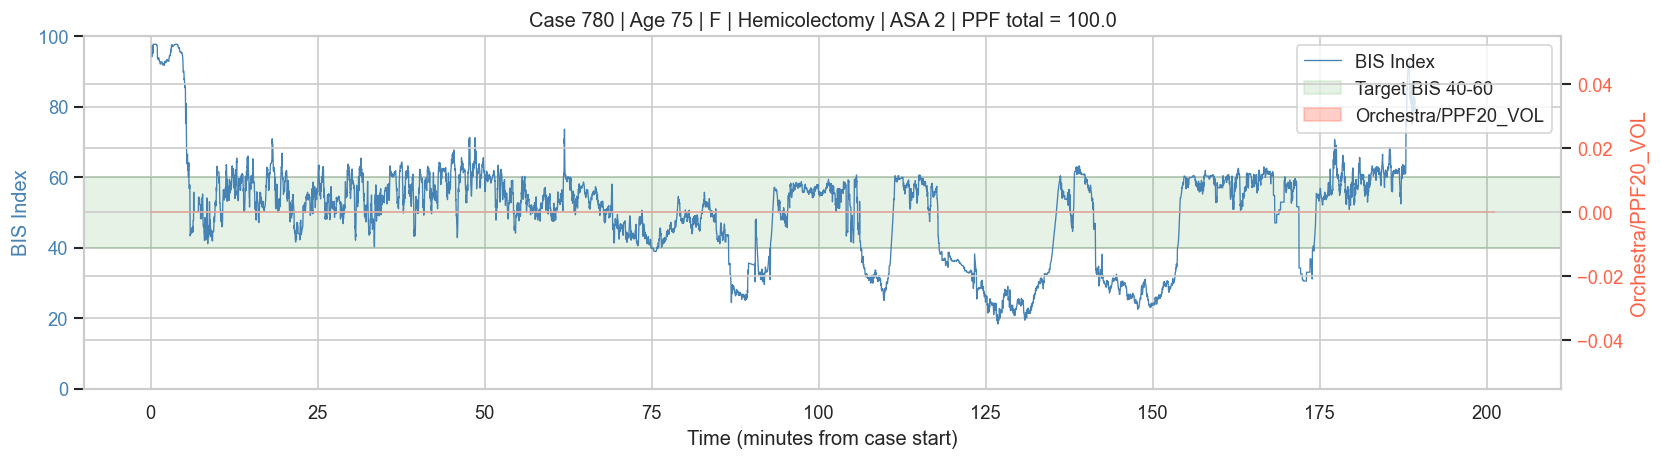

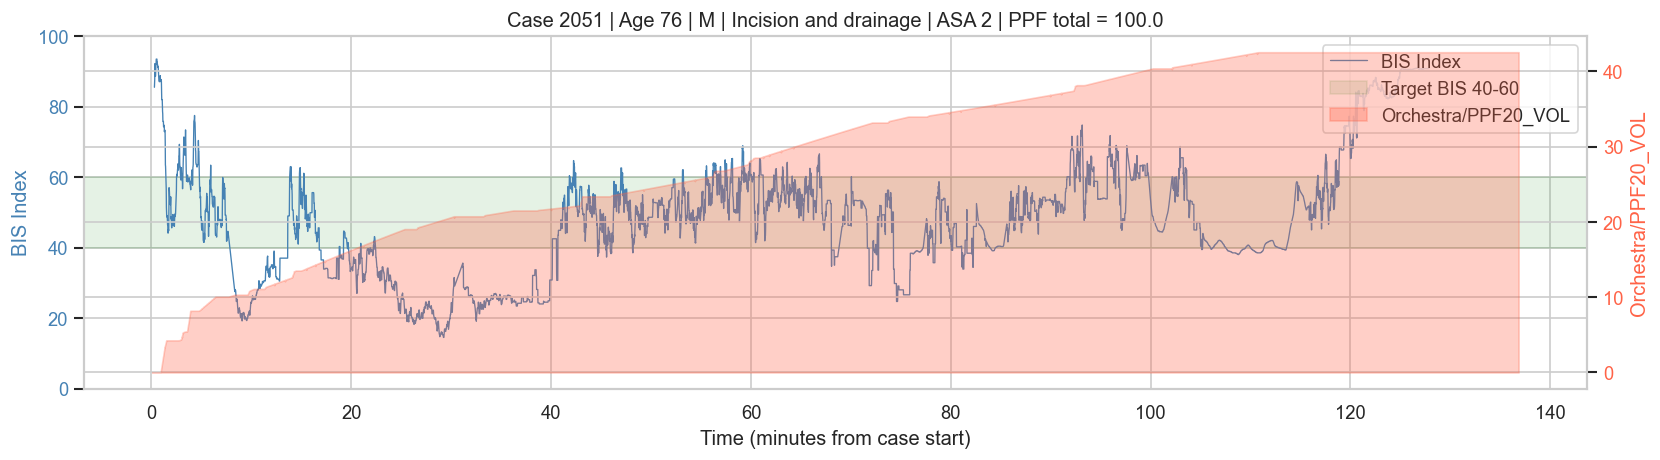

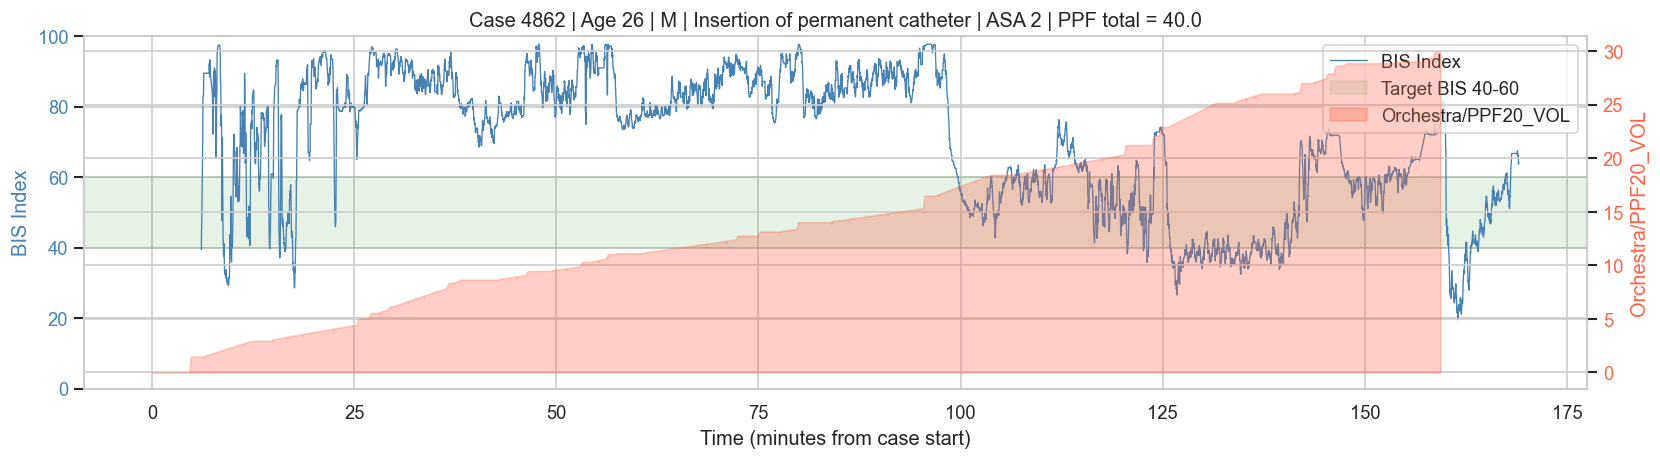

In [11]:
def plot_single_case(caseid, data, case_meta):
    """Plot BIS and propofol rate on dual-axis time chart for one case."""
    has_bis = 'BIS/BIS' in data
    has_ppf = top_ppf_track and top_ppf_track in data

    if not has_bis:
        print(f'Case {caseid}: no BIS data')
        return

    bis_df = data['BIS/BIS'].copy()
    time_col = bis_df.columns[0]  # first col is time
    val_col  = bis_df.columns[1]  # second col is value
    bis_df = bis_df.rename(columns={time_col: 'time', val_col: 'bis'})
    bis_df['time_min'] = bis_df['time'] / 60
    bis_df = bis_df[(bis_df['bis'] > 0) & (bis_df['bis'] <= 100)]

    meta = case_meta[case_meta['caseid'] == caseid].iloc[0]

    fig, ax1 = plt.subplots(figsize=(14, 4))

    ax1.plot(bis_df['time_min'], bis_df['bis'], color='steelblue', linewidth=0.8, label='BIS Index')
    ax1.axhspan(40, 60, alpha=0.1, color='green', label='Target BIS 40-60')
    ax1.set_xlabel('Time (minutes from case start)')
    ax1.set_ylabel('BIS Index', color='steelblue')
    ax1.set_ylim(0, 100)
    ax1.tick_params(axis='y', labelcolor='steelblue')

    if has_ppf:
        ppf_df = data[top_ppf_track].copy()
        tc = ppf_df.columns[0]
        vc = ppf_df.columns[1]
        ppf_df = ppf_df.rename(columns={tc: 'time', vc: 'ppf'})
        ppf_df['time_min'] = ppf_df['time'] / 60
        ppf_df = ppf_df[ppf_df['ppf'] >= 0]

        ax2 = ax1.twinx()
        ax2.fill_between(ppf_df['time_min'], ppf_df['ppf'],
                         alpha=0.3, color='tomato', label=f'{top_ppf_track}')
        ax2.set_ylabel(f'{top_ppf_track}', color='tomato')
        ax2.tick_params(axis='y', labelcolor='tomato')
        lines2, labels2 = ax2.get_legend_handles_labels()
    else:
        lines2, labels2 = [], []

    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    ax1.set_title(
        f'Case {caseid} | Age {meta.age:.0f} | {meta.sex} | {meta.opname} | '
        f'ASA {int(meta.asa)} | PPF total = {meta.intraop_ppf:.1f}'
    )
    plt.tight_layout()
    plt.show()


# Plot first 3 cases with data
plotted = 0
for cid, data in all_fetched.items():
    if 'BIS/BIS' in data:
        plot_single_case(cid, data, cohort)
        plotted += 1
    if plotted >= 3:
        break

### Reading the time-series: what patterns do you see?

In these individual traces, you can often spot the classic phases of a propofol-based anaesthetic:

1. **Induction** — a bolus or high infusion rate drives the BIS down sharply from awake levels (~90–97) to the anaesthetic range (~40–60) within a few minutes.
2. **Maintenance** — the infusion rate is adjusted (often automatically by the TCI pump) to keep the BIS within the target band. Notice how the BIS fluctuates — surgical stimulation (incision, tissue manipulation) tends to push it up, while the propofol brings it back down.
3. **Emergence** — towards the end, propofol delivery stops or decreases, and the BIS climbs back towards awake levels.

The **delay** between a change in propofol delivery and the BIS response is the *effect-site equilibration time* — it takes 1–3 minutes for propofol to travel from the blood to the brain. This delay is why TCI pumps use predictive models rather than simple feedback loops.

## How deeply anaesthetised were our patients, on average?

Now let us summarise each case's BIS recording into a handful of useful numbers:

- **Mean and median BIS** — the "typical" depth during the case
- **Minimum BIS** — how deep did it go at the worst point?
- **% time with BIS below 40** — how much of the case was spent in potentially excessive depth?
- **% time with BIS above 60** — how much of the case risked inadequate anaesthesia?

These summary statistics (sometimes called **BIS metrics**) let us compare across cases even though each operation lasted a different amount of time.

In [12]:
records = []
for cid, data in all_fetched.items():
    if 'BIS/BIS' not in data:
        continue
    bis_df = data['BIS/BIS'].copy()
    val_col = bis_df.columns[1]
    vals = bis_df[val_col].dropna()
    vals = vals[(vals > 0) & (vals <= 100)]
    if len(vals) < 10:
        continue

    meta = cohort[cohort['caseid'] == cid].iloc[0]
    records.append({
        'caseid'         : cid,
        'mean_bis'       : vals.mean(),
        'median_bis'     : vals.median(),
        'min_bis'        : vals.min(),
        'max_bis'        : vals.max(),
        'std_bis'        : vals.std(),
        'pct_below40'    : (vals < 40).mean() * 100,  # burst suppression risk
        'pct_above60'    : (vals > 60).mean() * 100,  # possible awareness risk
        'intraop_ppf'    : meta['intraop_ppf'],
        'age'            : meta['age'],
        'asa'            : meta['asa'],
        'death_inhosp'   : meta['death_inhosp'],
        'icu_days'       : meta['icu_days'],
    })

bis_stats = pd.DataFrame(records)
print(f'Cases with valid BIS stats: {len(bis_stats)}')
bis_stats[['mean_bis', 'median_bis', 'min_bis', 'pct_below40', 'pct_above60', 'intraop_ppf']].describe().round(2)

Cases with valid BIS stats: 8


,mean_bis,median_bis,min_bis,pct_below40,pct_above60,intraop_ppf
count,8.00,8.00,8.00,8.00,8.00,8.00
mean,48.42,48.81,21.28,26.18,16.09,64.75
std,9.44,11.92,5.05,18.35,21.51,41.10
min,38.30,35.60,14.50,9.51,3.09,8.00
25%,44.82,43.92,18.12,13.37,4.41,32.50
50%,46.10,45.55,20.40,21.08,7.69,80.00
75%,48.56,49.70,23.35,31.70,17.27,100.00
max,70.08,75.50,29.60,65.95,67.24,100.00


## Does more propofol mean a lower BIS?

This is the central question. If propofol is doing its job, we would expect patients who received *higher* doses to have *lower* average BIS values. Let us test this intuition with three scatter plots:

1. **Total propofol dose vs mean BIS** — the headline relationship
2. **Dose vs % time BIS < 40** — does more propofol push patients into dangerously deep territory?
3. **Dose vs % time BIS > 60** — does less propofol leave patients inadequately anaesthetised?

Each dot represents one patient. The red dashed line is a simple linear **trend line** — a straight line fitted to the data to highlight the overall direction of the relationship. If the line slopes downward, it means higher doses are associated with lower BIS (as expected).

*Note:* A straight line is a simplification. As we discussed earlier, the true propofol–BIS relationship is sigmoid, not linear. But a linear trend is a useful first approximation to see whether the expected direction holds in our data.

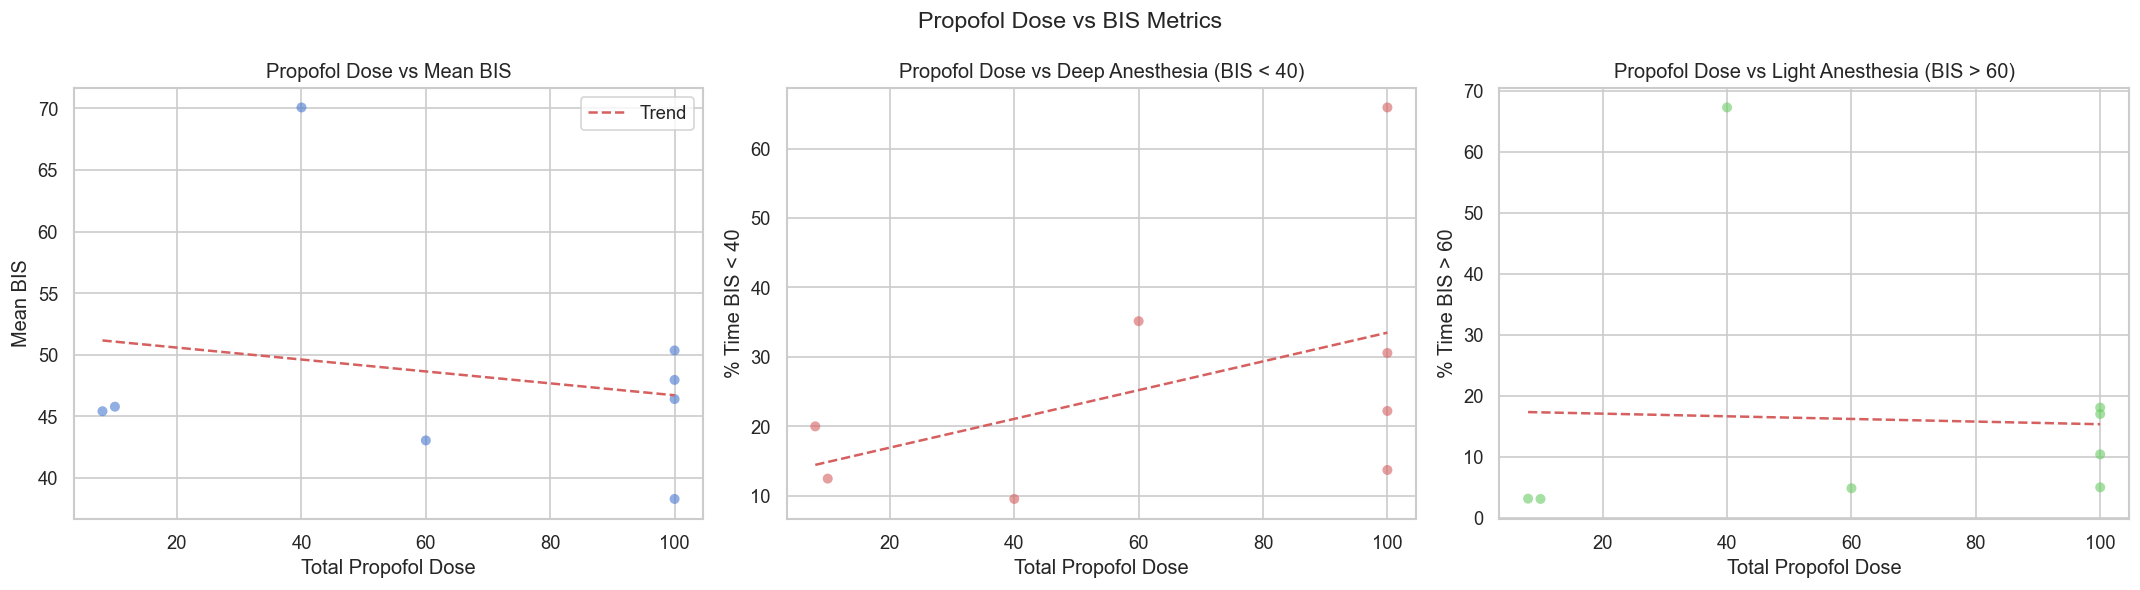

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: PPF dose vs mean BIS
axes[0].scatter(bis_stats['intraop_ppf'], bis_stats['mean_bis'],
                alpha=0.6, color=sns.color_palette('muted')[0], edgecolors='none')
z = np.polyfit(bis_stats['intraop_ppf'].dropna(), bis_stats['mean_bis'].dropna(), 1)
x_line = np.linspace(bis_stats['intraop_ppf'].min(), bis_stats['intraop_ppf'].max(), 100)
axes[0].plot(x_line, np.polyval(z, x_line), 'r--', linewidth=1.5, label='Trend')
axes[0].set_xlabel('Total Propofol Dose')
axes[0].set_ylabel('Mean BIS')
axes[0].set_title('Propofol Dose vs Mean BIS')
axes[0].legend()

# Scatter: PPF dose vs % time BIS < 40 (deep)
axes[1].scatter(bis_stats['intraop_ppf'], bis_stats['pct_below40'],
                alpha=0.6, color=sns.color_palette('muted')[3], edgecolors='none')
z2 = np.polyfit(bis_stats['intraop_ppf'].dropna(), bis_stats['pct_below40'].dropna(), 1)
axes[1].plot(x_line, np.polyval(z2, x_line), 'r--', linewidth=1.5)
axes[1].set_xlabel('Total Propofol Dose')
axes[1].set_ylabel('% Time BIS < 40')
axes[1].set_title('Propofol Dose vs Deep Anesthesia (BIS < 40)')

# Scatter: PPF dose vs % time BIS > 60 (light)
axes[2].scatter(bis_stats['intraop_ppf'], bis_stats['pct_above60'],
                alpha=0.6, color=sns.color_palette('muted')[2], edgecolors='none')
z3 = np.polyfit(bis_stats['intraop_ppf'].dropna(), bis_stats['pct_above60'].dropna(), 1)
axes[2].plot(x_line, np.polyval(z3, x_line), 'r--', linewidth=1.5)
axes[2].set_xlabel('Total Propofol Dose')
axes[2].set_ylabel('% Time BIS > 60')
axes[2].set_title('Propofol Dose vs Light Anesthesia (BIS > 60)')

plt.suptitle('Propofol Dose vs BIS Metrics', fontsize=14)
plt.tight_layout()
plt.show()

### Interpreting the scatter plots

The relationship between total propofol dose and mean BIS may be weaker than you expected. Why?

1. **Dose is not the same as concentration.** Two patients may receive the same total dose but have very different *effect-site concentrations* because of differences in body composition, cardiac output, and metabolism. The sigmoid model operates on concentration, not dose.
2. **BIS is actively managed.** Anaesthesiologists titrate propofol *to a target BIS*. If the BIS drifts up, they give more; if it drifts down, they give less. This **feedback loop** deliberately weakens the dose–BIS correlation — which is actually a sign of good clinical practice!
3. **Small sample.** We only have detailed time-series data for a handful of cases due to API availability. The correlations will stabilise with larger samples.

The take-home message: in a well-managed anaesthetic, the correlation between propofol dose and BIS *should* be modest, because the anaesthesiologist is actively closing the loop.

## Do patients who receive more propofol have different BIS profiles?

Another way to examine the propofol–BIS relationship is to split patients into **dose tertiles** — low, medium, and high propofol doses — and compare their BIS metrics side by side using box plots.

A **box plot** (also called a box-and-whisker plot) is a compact way to show the spread of data:
- The box spans from the 25th to the 75th percentile (the middle 50% of values)
- The line inside the box is the **median** (the middle value)
- The whiskers extend to the most extreme points within 1.5 times the box width

If higher propofol doses push patients deeper, we should see the "High PPF" group with lower mean BIS and higher % time below 40.

/var/folders/7x/kwqz48wj79v4vxlgr391kxbh0000gp/T/ipykernel_16082/1446282120.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Low PPF', 'Mid PPF', 'High PPF'],
/var/folders/7x/kwqz48wj79v4vxlgr391kxbh0000gp/T/ipykernel_16082/1446282120.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Low PPF', 'Mid PPF', 'High PPF'],
/var/folders/7x/kwqz48wj79v4vxlgr391kxbh0000gp/T/ipykernel_16082/1446282120.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Low PPF', 'Mid PPF', 'High PPF'],


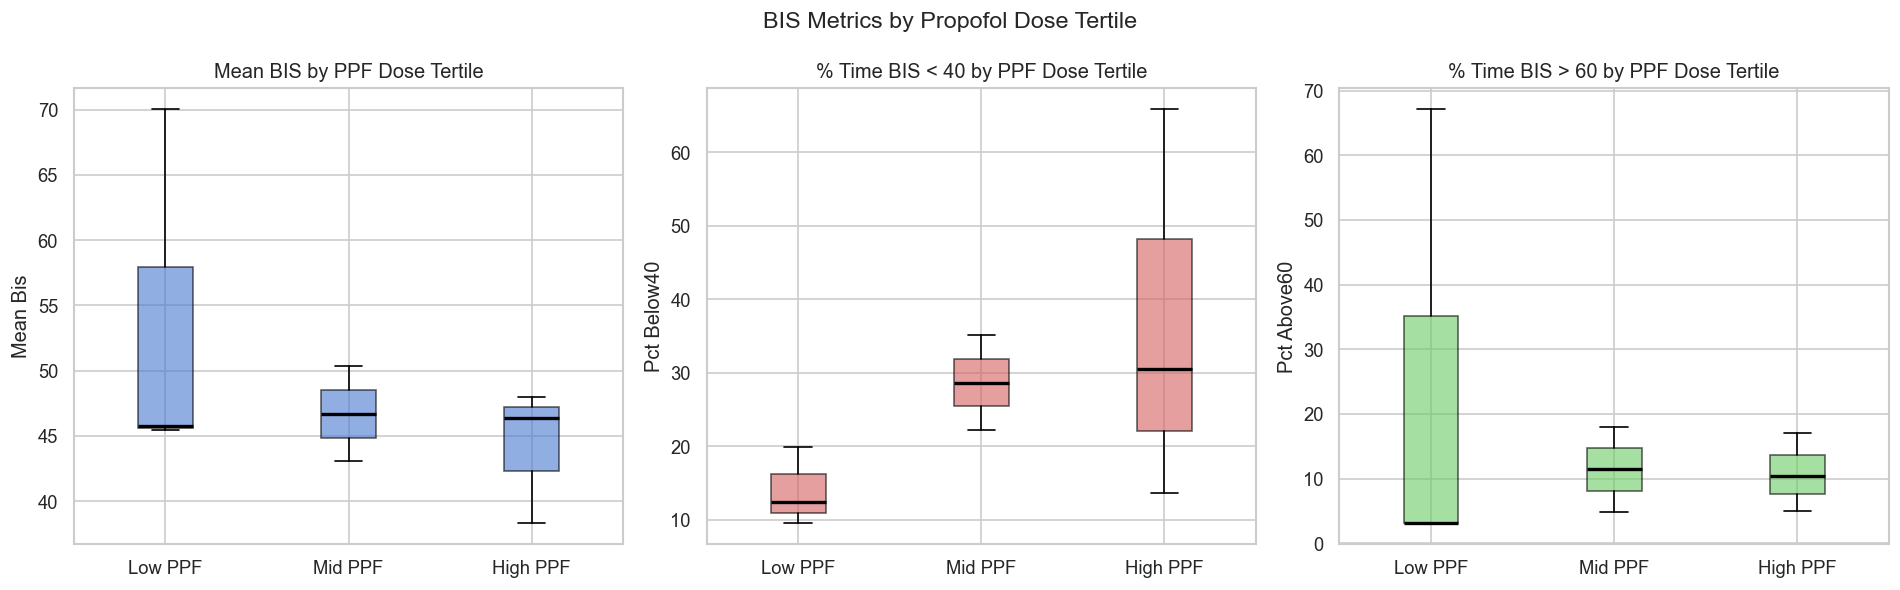

In [14]:
# BIS distributions across propofol dose tertiles
bis_stats['ppf_tertile'] = pd.qcut(
    bis_stats['intraop_ppf'].rank(method='first'),
    q=3, labels=['Low PPF', 'Mid PPF', 'High PPF']
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette('muted')

for ax, (metric, title, color_idx) in zip(axes, [
    ('mean_bis',    'Mean BIS by PPF Dose Tertile',         0),
    ('pct_below40', '% Time BIS < 40 by PPF Dose Tertile', 3),
    ('pct_above60', '% Time BIS > 60 by PPF Dose Tertile', 2),
]):
    groups = [bis_stats.loc[bis_stats['ppf_tertile'] == t, metric].dropna()
              for t in ['Low PPF', 'Mid PPF', 'High PPF']]
    ax.boxplot(groups, labels=['Low PPF', 'Mid PPF', 'High PPF'],
               patch_artist=True,
               boxprops=dict(facecolor=palette[color_idx], alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(metric.replace('_', ' ').title())

plt.suptitle('BIS Metrics by Propofol Dose Tertile', fontsize=14)
plt.tight_layout()
plt.show()

## What does the "average" anaesthetic look like?

Each case lasts a different amount of time, so we cannot simply overlay the raw BIS traces. Instead, we **time-normalise** each trace — stretching or compressing it so that 0% represents the start and 100% represents the end of the case. This lets us compute a **population-averaged BIS profile**: the typical BIS trajectory from induction to emergence.

We split cases by propofol dose tertile (low, mid, high) and show the **median** (solid line) with the **interquartile range** (shaded area) for each group. The shaded band between these lines captures the middle 50% of patients — think of it as the "normal range" of BIS at each time point.

Look for the characteristic U-shape: BIS starts high (awake), drops sharply at induction, stays in the maintenance range for most of the case, and rises again at emergence.

Cases available for normalised plot: 8


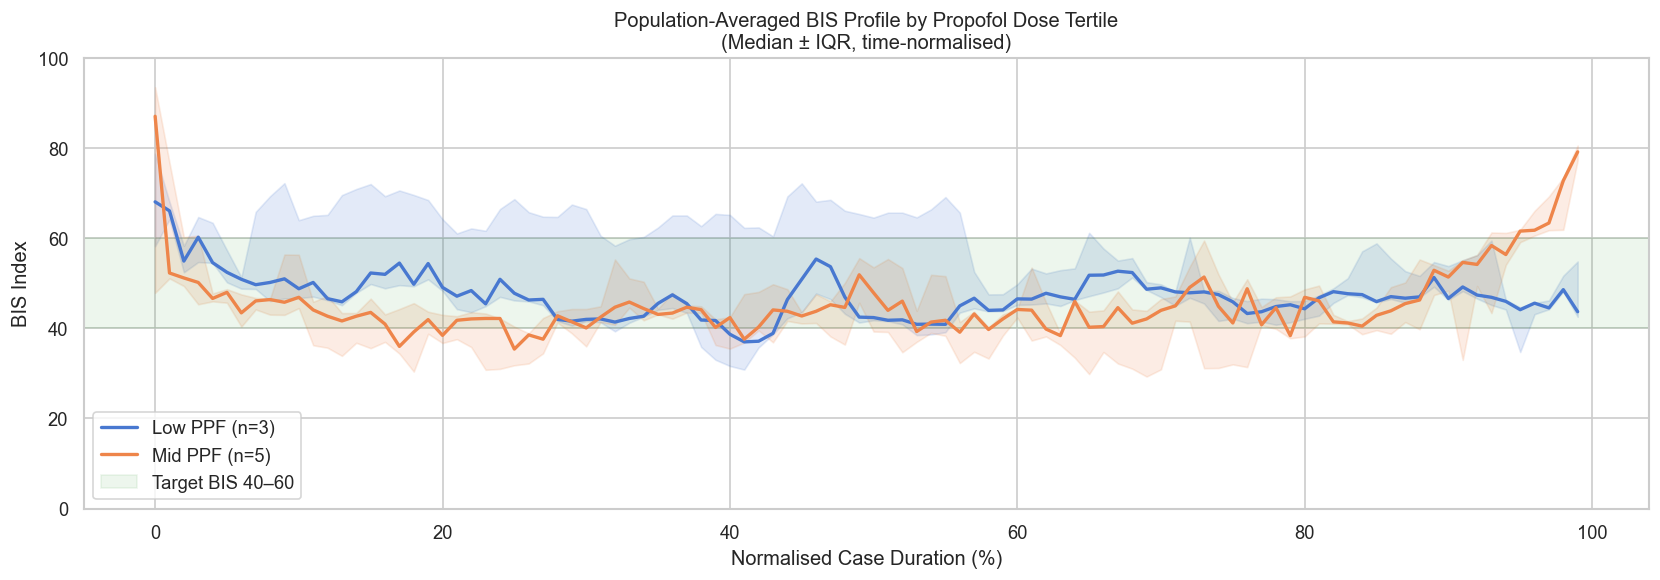

In [15]:
N_BINS = 100  # percent of case duration

normalised = []
for cid, data in all_fetched.items():
    if 'BIS/BIS' not in data:
        continue
    bis_df = data['BIS/BIS'].copy()
    time_col = bis_df.columns[0]
    val_col  = bis_df.columns[1]
    df = bis_df[[time_col, val_col]].rename(columns={time_col: 't', val_col: 'bis'})
    df = df[(df['bis'] > 0) & (df['bis'] <= 100)].dropna()
    if len(df) < 20:
        continue
    # Normalise time to 0-100%
    df['t_norm'] = (df['t'] - df['t'].min()) / (df['t'].max() - df['t'].min()) * 100
    df['t_bin']  = pd.cut(df['t_norm'], bins=N_BINS, labels=False)
    binned = df.groupby('t_bin')['bis'].median()
    meta = cohort[cohort['caseid'] == cid].iloc[0]
    normalised.append({'caseid': cid, 'ppf': meta['intraop_ppf'], 'trace': binned})

print(f'Cases available for normalised plot: {len(normalised)}')

# Split into tertiles for comparison
ppf_vals_n = np.array([r['ppf'] for r in normalised])
t1, t2 = np.percentile(ppf_vals_n, [33, 67])
groups_n = {
    'Low PPF'  : [r['trace'] for r in normalised if r['ppf'] <= t1],
    'Mid PPF'  : [r['trace'] for r in normalised if t1 < r['ppf'] <= t2],
    'High PPF' : [r['trace'] for r in normalised if r['ppf'] > t2],
}

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('muted')
x_axis = np.arange(N_BINS)

for (label, traces), color in zip(groups_n.items(), [colors[0], colors[1], colors[3]]):
    if not traces:
        continue
    mat = pd.concat(traces, axis=1).values
    med = np.nanmedian(mat, axis=1)
    q25 = np.nanpercentile(mat, 25, axis=1)
    q75 = np.nanpercentile(mat, 75, axis=1)
    ax.plot(x_axis, med, color=color, linewidth=2, label=f'{label} (n={len(traces)})')
    ax.fill_between(x_axis, q25, q75, color=color, alpha=0.15)

ax.axhspan(40, 60, alpha=0.07, color='green', label='Target BIS 40–60')
ax.set_xlabel('Normalised Case Duration (%)')
ax.set_ylabel('BIS Index')
ax.set_ylim(0, 100)
ax.set_title('Population-Averaged BIS Profile by Propofol Dose Tertile\n(Median ± IQR, time-normalised)')
ax.legend()
plt.tight_layout()
plt.show()

## How do all these variables relate to each other?

A **correlation matrix** is a table that shows the **Pearson correlation coefficient** (r) between every pair of variables. The value of r ranges from -1 to +1:

- **r = +1** means a perfect positive relationship (as one goes up, the other goes up in lockstep)
- **r = -1** means a perfect negative relationship (as one goes up, the other goes down)
- **r = 0** means no linear relationship at all

In the heatmap below, **red** cells indicate positive correlations and **blue** cells indicate negative correlations. The deeper the colour, the stronger the relationship.

Pay particular attention to:
- The row/column for **intraop_ppf** (total propofol dose) — how strongly does it correlate with the various BIS metrics?
- **Age** — older patients are generally more sensitive to propofol. Do you see that reflected here?
- **ASA class** — does patient comorbidity relate to BIS depth?

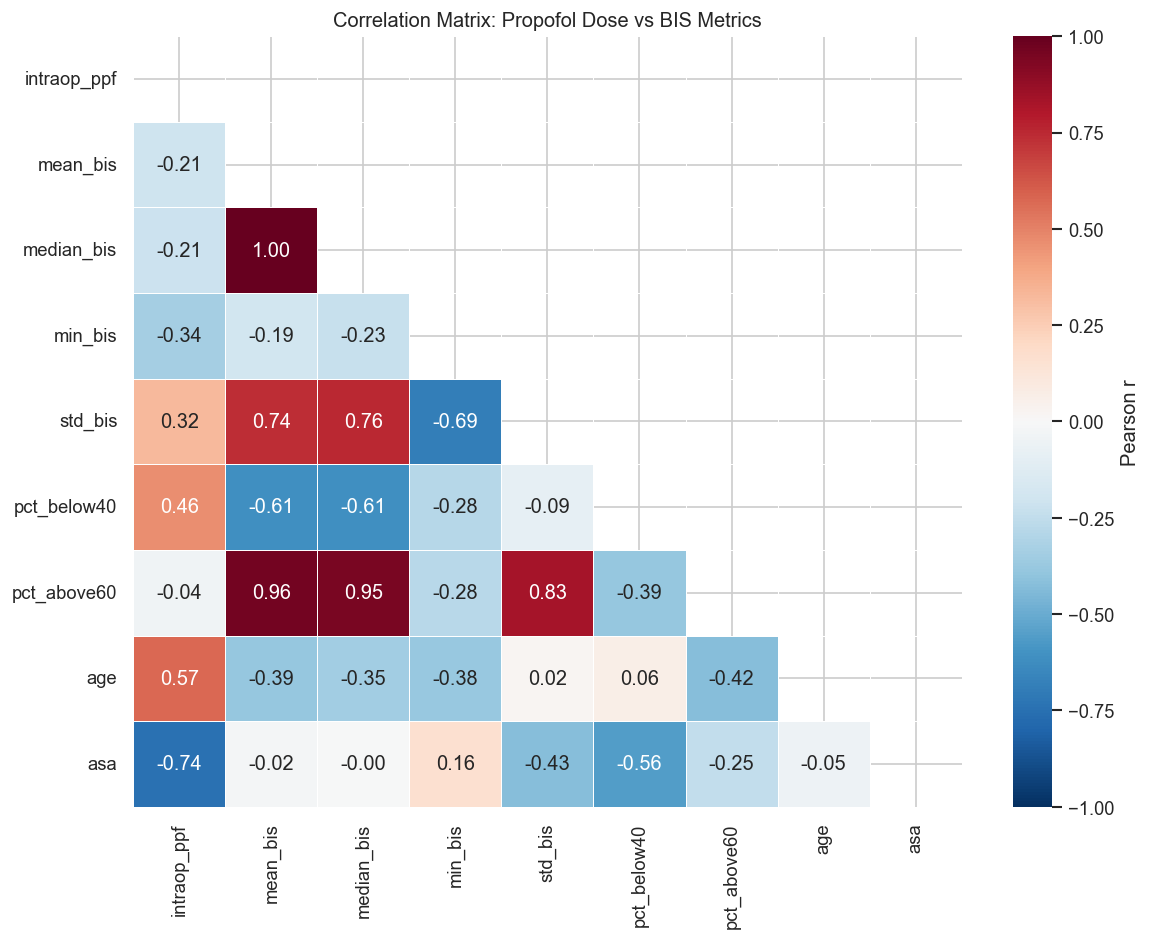

In [16]:
corr_cols = ['intraop_ppf', 'mean_bis', 'median_bis', 'min_bis',
             'std_bis', 'pct_below40', 'pct_above60', 'age', 'asa']
corr = bis_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix: Propofol Dose vs BIS Metrics')
plt.tight_layout()
plt.show()

## Were patients kept at the right depth? Classifying BIS adequacy

In clinical practice, a BIS value between 40 and 60 is generally considered **adequate** for general anaesthesia. But how often do real-world cases actually stay in this range?

Here we classify each case into one of three categories:
- **Adequate** — the BIS was in the 40–60 range for most of the case (neither too deep nor too light for more than 20% of the time)
- **Predominantly Deep** — BIS was below 40 for more than 20% of the case, suggesting excessive anaesthetic depth. This has been associated with **burst suppression** on EEG and, in some studies, with increased postoperative delirium and mortality in elderly patients.
- **Predominantly Light** — BIS was above 60 for more than 20% of the case, raising concern about **inadequate anaesthesia** and the risk of intraoperative awareness.

The pie chart shows the overall breakdown, and the box plot asks: *did the "too deep" group receive more propofol, or were they simply more sensitive to it?*

/var/folders/7x/kwqz48wj79v4vxlgr391kxbh0000gp/T/ipykernel_16082/377630919.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(ppf_by_adequacy, labels=[g.split('(')[0].strip() for g in adequacy_counts.index],


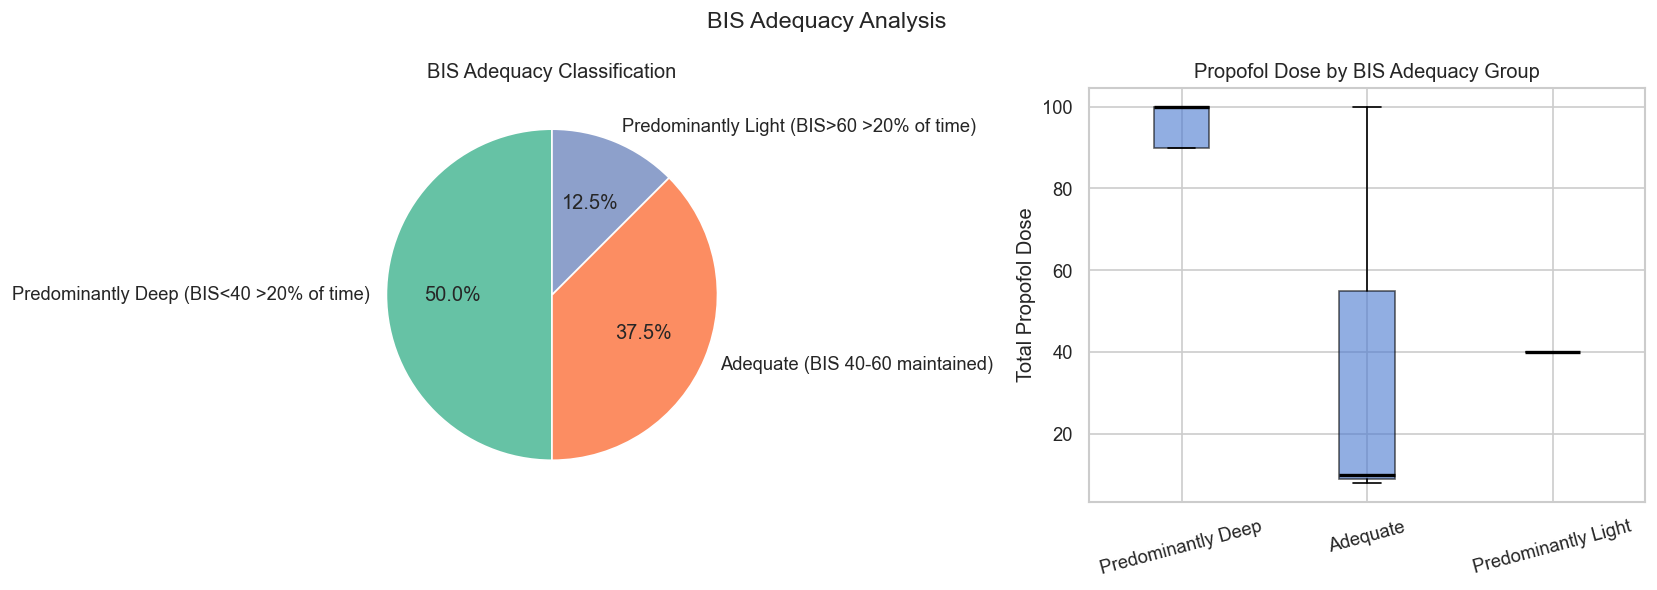


BIS adequacy breakdown:
adequacy
Predominantly Deep (BIS<40 >20% of time)     4
Adequate (BIS 40-60 maintained)              3
Predominantly Light (BIS>60 >20% of time)    1


In [17]:
def classify_bis_adequacy(row):
    if row['pct_below40'] > 20:
        return 'Predominantly Deep (BIS<40 >20% of time)'
    elif row['pct_above60'] > 20:
        return 'Predominantly Light (BIS>60 >20% of time)'
    else:
        return 'Adequate (BIS 40-60 maintained)'

bis_stats['adequacy'] = bis_stats.apply(classify_bis_adequacy, axis=1)
adequacy_counts = bis_stats['adequacy'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(adequacy_counts, labels=adequacy_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90)
axes[0].set_title('BIS Adequacy Classification')

# Propofol dose by adequacy group
ppf_by_adequacy = [bis_stats.loc[bis_stats['adequacy'] == g, 'intraop_ppf'].dropna()
                   for g in adequacy_counts.index]
axes[1].boxplot(ppf_by_adequacy, labels=[g.split('(')[0].strip() for g in adequacy_counts.index],
                patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[0], alpha=0.6),
                medianprops=dict(color='black', linewidth=2),
                showfliers=False)
axes[1].set_title('Propofol Dose by BIS Adequacy Group')
axes[1].set_ylabel('Total Propofol Dose')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('BIS Adequacy Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print('\nBIS adequacy breakdown:')
print(adequacy_counts.to_string())

### What does this mean for clinical practice?

The adequacy classification reveals a striking finding: a substantial proportion of cases spent significant time outside the target BIS range. This is consistent with the anaesthesia literature — even with BIS monitoring, maintaining the "ideal" depth is harder than it sounds.

Several factors contribute:
- **Surgical stimulation** (incision, retraction) can transiently raise the BIS faster than the infusion rate can compensate
- **Pharmacokinetic variability** — the same dose produces different concentrations in different patients
- **Alarm fatigue** — when monitors beep frequently, clinicians may be slower to respond
- **Clinical judgement** — sometimes an anaesthesiologist deliberately allows a slightly lower or higher BIS depending on the surgical phase

The fact that "predominantly deep" cases do not necessarily receive the highest propofol doses suggests that individual **sensitivity** (a lower EC50 or steeper Hill coefficient) plays as big a role as the dose itself. This is exactly what the sigmoid Emax model predicts.

## What have we learned?

Let us bring it all together with a numerical summary of the propofol–BIS analysis.

In [18]:
ppf_bis_corr = bis_stats['intraop_ppf'].corr(bis_stats['mean_bis'])
ppf_deep_corr = bis_stats['intraop_ppf'].corr(bis_stats['pct_below40'])

print('=' * 60)
print('PROPOFOL vs BIS — ANALYSIS SUMMARY')
print('=' * 60)
print(f'Analysis cohort          : {len(cohort_ids):,} cases')
print(f'Cases fetched & analyzed : {len(bis_stats):,}')
print()
print(f'Mean BIS (cohort)        : {bis_stats["mean_bis"].mean():.1f} ± {bis_stats["mean_bis"].std():.1f}')
print(f'% cases with BIS < 40 (>20% time): {(bis_stats["pct_below40"] > 20).mean()*100:.1f}%')
print(f'% cases with BIS > 60 (>20% time): {(bis_stats["pct_above60"] > 20).mean()*100:.1f}%')
print()
print(f'PPF dose vs mean BIS correlation  : r = {ppf_bis_corr:.3f}')
print(f'PPF dose vs deep anesthesia corr  : r = {ppf_deep_corr:.3f}')
print('=' * 60)

PROPOFOL vs BIS — ANALYSIS SUMMARY
Analysis cohort          : 2,100 cases
Cases fetched & analyzed : 8

Mean BIS (cohort)        : 48.4 ± 9.4
% cases with BIS < 40 (>20% time): 50.0%
% cases with BIS > 60 (>20% time): 12.5%

PPF dose vs mean BIS correlation  : r = -0.210
PPF dose vs deep anesthesia corr  : r = 0.464


## Key takeaways

1. **The propofol–BIS relationship is real but complex.** Higher propofol doses are associated with lower BIS values and more time in deep anaesthesia, but the correlation is modest because anaesthesiologists actively titrate to a target.

2. **Dose is not destiny.** Individual pharmacokinetic and pharmacodynamic variability means that the *same dose* produces *different depths* in different patients. This is why BIS monitoring exists — to close the gap between what the model predicts and what the patient actually experiences.

3. **The sigmoid Emax model captures the essential pharmacology.** The propofol–BIS relationship is nonlinear: small dose changes matter most in the steep middle portion of the curve (around the EC50), while very high or very low concentrations have diminishing returns.

4. **Maintaining target BIS is harder than it looks.** Even in this modern dataset with TCI pumps and BIS monitoring, a substantial fraction of cases drifted outside the 40–60 range for significant periods.

5. **Observational data shows associations, not causation.** Higher propofol doses may be associated with worse outcomes, but this likely reflects confounding by patient severity and surgical complexity rather than a direct harmful effect of the drug.

### Where to go from here

- **Chapter 14 (EEG Spectral Analysis)** dives deeper into what the BIS number actually measures — the raw EEG frequency spectrum that underlies it.
- **Chapter 11.2 (The Anaesthetic Triad)** explores how propofol interacts with haemodynamics (MAP and cardiac output) simultaneously.
- **Chapter 9 (Logistic Regression)** provides the statistical tools to formally model the dose–response relationship while controlling for confounders.